# Chess Elo Prediction — BiLSTM + Static Features

Predict White and Black Elo from move sequences, clock data, and board features.  
Multi-task BiLSTM with attention; trained on Lichess standard-rated games.

**Toggle any section via `FEATURE_GROUPS` and `USE_SEQUENTIAL` in the Config cell.**

In [25]:
import io, re, os, time, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zstandard as zstd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, median_absolute_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, normalize
from scipy import stats
from joblib import Parallel, delayed

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import chess_features_final as cff

warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

## Config

In [ ]:
# ── paths & data ─────────────────────────────────────────────────────────────
DATA_PATH    = '../../data/elias_data/lichess_db_standard_rated_2017-05.pgn.zst'
MAX_GAMES    = 200_000        # start here; bump to 1M for full runs
RANDOM_STATE = 42

# ── time-control filter ───────────────────────────────────────────────────────
TIME_CONTROL  = '600+0'   # exact match like '300+0'; set None to skip
TC_BASE_MIN   = None
TC_BASE_MAX   = None
TC_INC_MIN    = None
TC_INC_MAX    = None
EXCLUDE_TERMS = {'Time forfeit', 'Abandoned', 'Unterminated'}

# ── sequence settings ─────────────────────────────────────────────────────────
MIN_PLIES   = 12
MAX_SEQ_LEN = 120

# ── model hyperparams ─────────────────────────────────────────────────────────
#
#  CPU-only laptop (recommended starting point)
#    EMBED_DIM=64, HIDDEN_DIM=128, BATCH_SIZE=64, NUM_EPOCHS=10
#    ~200k games takes roughly 2-3 h on a modern 8-core machine.
#
#  GPU available (mid-range card, e.g. RTX 3060)
#    EMBED_DIM=128, HIDDEN_DIM=256, BATCH_SIZE=256 — no other changes needed.
#    Mixed-precision (AMP) kicks in automatically when CUDA is detected.
#
EMBED_DIM    = 64
HIDDEN_DIM   = 128      # bump to 256 on GPU
BATCH_SIZE   = 64       # bump to 256 on GPU; keep <=128 on CPU
NUM_EPOCHS   = 15
LR           = 3e-4     # AdamW with cosine schedule
DROPOUT      = 0.25
WEIGHT_DECAY = 1e-4
PATIENCE     = 3        # early-stopping patience
REL_DELTA    = 0.01    # 1% improvement counts as progress
NUM_WORKERS  = 0
VAL_FRAC     = 0.10
TEST_FRAC    = 0.10

# ── feature toggles ───────────────────────────────────────────────────────────
#
#  USE_SEQUENTIAL = True   BiLSTM branch over move tokens is active.
#  USE_SEQUENTIAL = False  Static/clock features only (fast CPU baseline).
#                          Run once to know your baseline MAE before enabling LSTM.
#
USE_SEQUENTIAL = True

FEATURE_GROUPS = {
    'game_structure': True,   # total_ply_count, material_balance, result_encoded
    'checks':         True,   # checks_given_*, check_density_*
    'captures':       True,   # first_capture_*, pawn/piece_captures, capture_density
    'castling':       True,   # castle_move_*, castle_side_* (one-hot encoded)
    'style':          True,   # consec_same_piece, queen_before_10, territory_depth,
                              #   promotions, en_passant, legal_moves_*5
    'engine_quality': True,   # acpl_*, inaccuracy/mistake/blunder counts + density
    'clock':          True,   # w_/b_ avg/std/max_time_norm, time_pressure, opening_pace
    'tc_meta':        True,   # tc_base, tc_inc
}

# column-prefix -> feature group  (used for auto-selection and ablation)
_GROUP_PREFIXES = {
    'game_structure': ['total_ply', 'material_balance', 'result_encoded'],
    'checks':         ['checks_given', 'check_density'],
    'captures':       ['first_capture', 'pawn_captures', 'piece_captures', 'capture_density'],
    'castling':       ['castle_move', 'castle_side'],
    'style':          ['consec_same', 'queen_moves', 'white_territory', 'black_territory',
                       'promotions', 'en_passant', 'legal_moves'],
    'engine_quality': ['acpl', 'inaccuracy', 'mistake', 'blunder'],
    'clock':          ['w_avg_time', 'w_std_time', 'w_max_time', 'w_time_pressure',
                       'w_opening_pace', 'b_avg_time', 'b_std_time', 'b_max_time',
                       'b_time_pressure', 'b_opening_pace'],
    'tc_meta':        ['tc_base', 'tc_inc'],
}

ELO_BINS = [0, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2500, 4000]
CPU_THREADS = os.cpu_count() or 4
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = (device.type == 'cuda')
print(f'Device : {device}  |  AMP : {USE_AMP}')
print(f'Sequential branch : {USE_SEQUENTIAL}')
print(f'embed={EMBED_DIM}  hidden={HIDDEN_DIM}  bs={BATCH_SIZE}  '
      f'lr={LR}  dropout={DROPOUT}  epochs={NUM_EPOCHS}')

# Apply CPU thread settings (no effect on CUDA kernels)
torch.set_num_threads(CPU_THREADS)
torch.set_num_interop_threads(max(1, CPU_THREADS // 2))

print(f'Device : {device}  |  AMP : {USE_AMP}')
print(f'CPU threads: {CPU_THREADS}')


Device : cpu  |  AMP : False
Sequential branch : True
embed=64  hidden=128  bs=64  lr=0.0003  dropout=0.25  epochs=15


## Data Loading

In [27]:
def load_pgn_zst(path, max_games):
    """Stream-parse a .pgn.zst file; returns a DataFrame of headers + move text."""
    records = []
    with open(path, 'rb') as fh:
        dctx   = zstd.ZstdDecompressor()
        reader = dctx.stream_reader(fh)
        stream = io.TextIOWrapper(reader, encoding='utf-8', errors='replace')
        headers, moves_lines, in_moves = {}, [], False
        for line in stream:
            line = line.strip()
            if line.startswith('['):
                in_moves = False
                m = re.match(r'\[(\w+)\s+"(.*)"\]', line)
                if m:
                    headers[m.group(1)] = m.group(2)
            elif line == '':
                if headers and moves_lines:
                    headers['Moves'] = ' '.join(moves_lines)
                    records.append(headers)
                    headers, moves_lines = {}, []
                    if len(records) >= max_games:
                        break
                elif headers:
                    in_moves = True
            else:
                if in_moves or headers:
                    moves_lines.append(line)
        if headers and moves_lines and len(records) < max_games:
            headers['Moves'] = ' '.join(moves_lines)
            records.append(headers)
    return pd.DataFrame(records)

t0 = time.time()
df_raw = load_pgn_zst(DATA_PATH, MAX_GAMES)
print(f'Loaded {len(df_raw):,} games in {time.time()-t0:.1f}s')

for col in ['WhiteElo', 'BlackElo']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
df_raw.dropna(subset=['WhiteElo', 'BlackElo', 'Moves'], inplace=True)
df_raw['WhiteElo'] = df_raw['WhiteElo'].astype(int)
df_raw['BlackElo'] = df_raw['BlackElo'].astype(int)

if 'Termination' in df_raw.columns:
    before = len(df_raw)
    df_raw = df_raw[~df_raw['Termination'].isin(EXCLUDE_TERMS)].reset_index(drop=True)
    print(f'Removed {before - len(df_raw):,} games by termination')

tc_pat = re.compile(r'^(\d+)\+(\d+)')
def parse_tc(tc_str):
    m = tc_pat.match(str(tc_str))
    return (int(m.group(1)), int(m.group(2))) if m else (np.nan, np.nan)

df_raw[['tc_base', 'tc_inc']] = df_raw['TimeControl'].apply(
    lambda x: pd.Series(parse_tc(x)))
df_raw.dropna(subset=['tc_base'], inplace=True)
df_raw['tc_base'] = df_raw['tc_base'].astype(int)
df_raw['tc_inc']  = df_raw['tc_inc'].astype(int)

before = len(df_raw)
if TIME_CONTROL:
    df_raw = df_raw[df_raw['TimeControl'].astype(str) == TIME_CONTROL]
if TC_BASE_MIN is not None: df_raw = df_raw[df_raw['tc_base'] >= TC_BASE_MIN]
if TC_BASE_MAX is not None: df_raw = df_raw[df_raw['tc_base'] <= TC_BASE_MAX]
if TC_INC_MIN  is not None: df_raw = df_raw[df_raw['tc_inc']  >= TC_INC_MIN]
if TC_INC_MAX  is not None: df_raw = df_raw[df_raw['tc_inc']  <= TC_INC_MAX]
df_raw = df_raw.reset_index(drop=True)
print(f'Removed {before - len(df_raw):,} games by time-control filter')
print(f'Remaining: {len(df_raw):,} games')
print(f'Elo range — White {df_raw.WhiteElo.min()}–{df_raw.WhiteElo.max()}, '
      f'Black {df_raw.BlackElo.min()}–{df_raw.BlackElo.max()}')

Loaded 200,000 games in 6.5s
Removed 66,359 games by termination
Removed 109,753 games by time-control filter
Remaining: 23,433 games
Elo range — White 779–2586, Black 771–2398


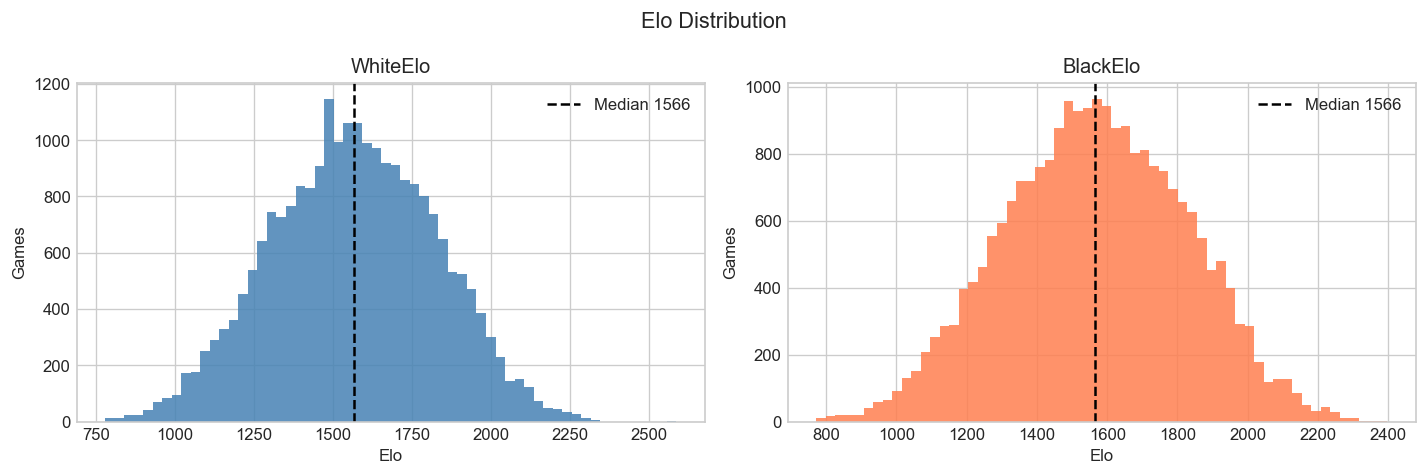

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in zip(axes, ['WhiteElo', 'BlackElo'], ['steelblue', 'coral']):
    ax.hist(df_raw[col], bins=60, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(df_raw[col].median(), color='black', lw=1.5, ls='--',
               label=f'Median {df_raw[col].median():.0f}')
    ax.set_xlabel('Elo'); ax.set_ylabel('Games')
    ax.set_title(col); ax.legend()
plt.suptitle('Elo Distribution', fontsize=13)
plt.tight_layout()
plt.show()

## Feature Extraction

In [29]:
# ── board features ───────────────────────────────────────────────────────────
print('Extracting board features (python-chess replay)...')
t0 = time.time()
board_feats = cff.extract_features_dataframe(df_raw, n_jobs=-1)
print(f'  Done in {time.time()-t0:.1f}s — {board_feats.shape[1]} columns')

# one-hot the categorical castle-side columns
for side in ['castle_side_white', 'castle_side_black']:
    if side in board_feats.columns:
        dummies = pd.get_dummies(board_feats[side], prefix=side)
        board_feats = pd.concat([board_feats.drop(columns=[side]), dummies], axis=1)

# ── clock features ────────────────────────────────────────────────────────────
_CLK_RE = re.compile(r'\[%clk\s+(\d+):(\d+):(\d+(?:\.\d+)?)\]')

def _extract_clocks(pgn_str):
    return [int(h)*3600 + int(m)*60 + float(s)
            for h, m, s in _CLK_RE.findall(pgn_str)]

def clock_features_row(pgn_str, tc_base):
    clocks = _extract_clocks(pgn_str)
    nan_d  = {k: np.nan for k in [
        'w_avg_time_norm','w_std_time_norm','w_max_time_norm',
        'w_time_pressure','w_opening_pace',
        'b_avg_time_norm','b_std_time_norm','b_max_time_norm',
        'b_time_pressure','b_opening_pace']}
    if len(clocks) < 4 or tc_base <= 0:
        return nan_d
    w_clk, b_clk = clocks[0::2], clocks[1::2]
    def _diffs(c):
        return [max(0.0, c[i]-c[i+1]) for i in range(len(c)-1)] if len(c)>1 else [0.0]
    def _stats(spent, remaining, tc):
        arr, rem = np.array(spent), np.array(remaining)
        return {
            'avg_time_norm':  float(arr.mean()/tc),
            'std_time_norm':  float(arr.std()/tc) if len(arr)>1 else 0.0,
            'max_time_norm':  float(arr.max()/tc),
            'time_pressure':  int(np.sum(rem[1:]<30)) if len(rem)>1 else 0,
            'opening_pace':   float(np.mean(spent[:5])/tc) if len(spent)>=5
                              else float(arr.mean()/tc),
        }
    ws = _stats(_diffs(w_clk), w_clk, tc_base)
    bs = _stats(_diffs(b_clk), b_clk, tc_base)
    return {f'w_{k}': v for k,v in ws.items()} | {f'b_{k}': v for k,v in bs.items()}

print('Extracting clock features...')
t0 = time.time()
clock_records = Parallel(n_jobs=-1)(
    delayed(clock_features_row)(m, tc)
    for m, tc in zip(df_raw['Moves'].tolist(), df_raw['tc_base'].tolist()))
clock_feats = pd.DataFrame(clock_records, index=df_raw.index)
print(f'  Done in {time.time()-t0:.1f}s — {clock_feats.shape[1]} columns')

df = pd.concat([df_raw, board_feats, clock_feats], axis=1)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'\nFull feature matrix: {df.shape}')

Extracting board features (python-chess replay)...
  Done in 15.7s — 35 columns
Extracting clock features...
  Done in 1.2s — 10 columns

Full feature matrix: (23433, 69)


## Move Tokenisation

In [30]:
class Vocab:
    """Minimal token vocabulary; PAD=0, UNK=1."""
    def __init__(self):
        self.move_to_id = {'<PAD>': 0, '<UNK>': 1}
        self._next = 2
    def add(self, token):
        if token not in self.move_to_id:
            self.move_to_id[token] = self._next
            self._next += 1
    def encode(self, token):
        return self.move_to_id.get(token, 1)
    def decode_map(self):
        return {v: k for k, v in self.move_to_id.items()}
    def __len__(self):
        return len(self.move_to_id)

_MOVE_RE     = re.compile(
    r'(?:\d+\.+\s*)?([KQRBN]?[a-h]?[1-8]?x?[a-h][1-8](?:=[QRBN])?[+#]?'
    r'|O-O-O[+#]?|O-O[+#]?)')
_EVAL_RE_TOK = re.compile(r'\[%eval\s+([^\]]+)\]')

def parse_pgn(pgn_str):
    moves  = _MOVE_RE.findall(pgn_str)
    clocks = _extract_clocks(pgn_str)
    evals  = []
    for m in _EVAL_RE_TOK.findall(pgn_str):
        try:
            evals.append(100.0 if '#' in m else float(m))
        except ValueError:
            evals.append(0.0)
    return moves, clocks, evals

print('Tokenising moves...')
parsed = df['Moves'].apply(parse_pgn)
df['clean_moves']  = parsed.apply(lambda x: x[0])
df['clean_clocks'] = parsed.apply(lambda x: x[1])
df['clean_evals']  = parsed.apply(lambda x: x[2])
df['n_moves']      = df['clean_moves'].apply(len)

before = len(df)
df = df[df['n_moves'] >= MIN_PLIES].reset_index(drop=True)
print(f'Dropped {before - len(df):,} short games (< {MIN_PLIES} plies)')

vocab = Vocab()
for move_list in df['clean_moves']:
    for m in move_list:
        vocab.add(m)

print(f'Vocab size : {len(vocab):,} unique tokens')
print(f'Games ready: {len(df):,}')

Tokenising moves...
Dropped 407 short games (< 12 plies)
Vocab size : 4,864 unique tokens
Games ready: 23,026


## Feature Selection & Scaling

In [31]:
_exclude     = {'WhiteElo', 'BlackElo', 'n_moves', 'tc_base', 'tc_inc'}
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in _exclude]

enabled_prefixes = []
for group, active in FEATURE_GROUPS.items():
    if active:
        enabled_prefixes.extend(_GROUP_PREFIXES.get(group, []))

def _col_in_group(col):
    return any(col.startswith(p) for p in enabled_prefixes)

static_cols = [c for c in numeric_cols if _col_in_group(c)]
num_static  = len(static_cols)
print(f'Static columns selected: {num_static}')
for g, active in FEATURE_GROUPS.items():
    mark = 'on ' if active else 'off'
    cnt  = sum(1 for c in static_cols
               if any(c.startswith(p) for p in _GROUP_PREFIXES.get(g, [])))
    print(f'  [{mark}] {g:<18s}  ({cnt} cols)')

# stratified split so every Elo bracket appears in all three sets
avg_elo   = (df['WhiteElo'] + df['BlackElo']) / 2
elo_strat = pd.cut(avg_elo, bins=ELO_BINS, labels=False).fillna(0).astype(int)
idx_train, idx_temp = train_test_split(
    df.index, test_size=VAL_FRAC + TEST_FRAC,
    stratify=elo_strat, random_state=RANDOM_STATE)
strat_temp = elo_strat.loc[idx_temp]
idx_val, idx_test = train_test_split(
    idx_temp, test_size=TEST_FRAC/(VAL_FRAC+TEST_FRAC),
    stratify=strat_temp, random_state=RANDOM_STATE)
print(f'\nSplit — train: {len(idx_train):,}  val: {len(idx_val):,}  test: {len(idx_test):,}')

# fit scaler on train only — never touch val/test before scaling
scaler = StandardScaler()
scaler.fit(df.loc[idx_train, static_cols].fillna(0))
df.loc[:, static_cols] = scaler.transform(df[static_cols].fillna(0))
print('Scaling done')

Static columns selected: 43
  [on ] game_structure      (3 cols)
  [on ] checks              (4 cols)
  [on ] captures            (5 cols)
  [on ] castling            (2 cols)
  [on ] style               (9 cols)
  [on ] engine_quality      (10 cols)
  [on ] clock               (10 cols)
  [on ] tc_meta             (0 cols)

Split — train: 18,420  val: 2,303  test: 2,303
Scaling done


## Dataset & DataLoaders

In [32]:
class ChessDataset(Dataset):
    """
    Stores all tensors in RAM after __init__ so __getitem__ is O(1).

    When use_seq=False (static-only mode) we still build 1-token sequences
    so collate_fn stays unchanged — the model just ignores the LSTM branch.
    """
    def __init__(self, df_sub, vocab, static_cols, use_seq=True):
        self.use_seq = use_seq
        self.samples = []
        static_arr = df_sub[static_cols].fillna(0).values.astype(np.float32)

        for i, (_, row) in enumerate(df_sub.iterrows()):
            tc = max(1, int(row.get('tc_base', 180)))
            if use_seq:
                moves = row['clean_moves'][:MAX_SEQ_LEN]
                ids   = [vocab.encode(m) for m in moves]
                L     = len(ids)
                raw   = row['clean_clocks'][:L]
                clks  = [min(max(c/tc, 0.0), 2.0) for c in raw]
                clks += [0.5] * (L - len(clks))
                turns = [float(j % 2) for j in range(L)]
            else:
                ids, clks, turns = [0], [0.5], [0.0]

            tgt = np.array([row['WhiteElo'], row['BlackElo']], dtype=np.float32)
            self.samples.append((
                torch.tensor(ids,           dtype=torch.long),
                torch.tensor(clks,          dtype=torch.float32),
                torch.tensor(turns,         dtype=torch.float32),
                torch.tensor(static_arr[i], dtype=torch.float32),
                torch.tensor(tgt,           dtype=torch.float32),
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ids, clks, turns, static, tgt = self.samples[idx]
        return {'moves': ids, 'clocks': clks, 'turns': turns,
                'static': static, 'targets': tgt}


def collate_fn(batch):
    moves_pad  = pad_sequence([b['moves'][:MAX_SEQ_LEN]  for b in batch],
                               batch_first=True, padding_value=0)
    clocks_pad = pad_sequence([b['clocks'][:MAX_SEQ_LEN] for b in batch],
                               batch_first=True, padding_value=0.0)
    turns_pad  = pad_sequence([b['turns'][:MAX_SEQ_LEN]  for b in batch],
                               batch_first=True, padding_value=0.0)
    return {
        'moves':   moves_pad,
        'clocks':  clocks_pad,
        'turns':   turns_pad,
        'mask':    (moves_pad != 0).float(),
        'static':  torch.stack([b['static']  for b in batch]),
        'targets': torch.stack([b['targets'] for b in batch]),
    }


print('Building datasets...')
t0 = time.time()
train_ds = ChessDataset(df.loc[idx_train], vocab, static_cols, USE_SEQUENTIAL)
val_ds   = ChessDataset(df.loc[idx_val],   vocab, static_cols, USE_SEQUENTIAL)
test_ds  = ChessDataset(df.loc[idx_test],  vocab, static_cols, USE_SEQUENTIAL)
print(f'  Built in {time.time()-t0:.1f}s')

pin = (device.type == 'cuda')
_kw = dict(batch_size=BATCH_SIZE, collate_fn=collate_fn, pin_memory=pin,
           num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS>0))
if NUM_WORKERS > 0:
    _kw['prefetch_factor'] = 2
train_loader = DataLoader(train_ds, shuffle=True,  **_kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **_kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **_kw)
print(f'Batches per epoch: {len(train_loader):,}')

Building datasets...
  Built in 3.2s
Batches per epoch: 288


## Model

In [33]:
class ChessEloPredictor(nn.Module):
    """
    Architecture overview
    ─────────────────────
    Sequential branch (optional, controlled by use_seq)
        Embedding  ->  BiLSTM (2 layers)  ->  soft-attention pooling
        Each time-step input: [move_embed | normalised_clock | turn_flag]

    Static branch
        MLP with LayerNorm: num_static -> 128 -> 64 -> 32

    Fusion
        concat(seq_context, static_out)  ->  shared MLP (256->128)  ->  two heads

    When use_seq=False the fusion only sees the static branch output (32-d).
    """

    def __init__(self, vocab_size, num_static, embed_dim, hidden_dim,
                 dropout, use_seq=True):
        super().__init__()
        self.use_seq = use_seq

        # sequential branch
        self.move_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim + 2,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout,
        )
        self.attn_proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

        # static branch
        self.static_fc1  = nn.Linear(num_static, 128)
        self.static_fc2  = nn.Linear(128, 64)
        self.static_fc3  = nn.Linear(64, 32)
        self.static_ln   = nn.LayerNorm(64)
        self.static_drop = nn.Dropout(dropout)

        # fusion + prediction heads
        seq_out_dim = hidden_dim * 2 if use_seq else 0
        self.shared = nn.Sequential(
            nn.Linear(seq_out_dim + 32, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )
        self.white_head = nn.Linear(128, 1)
        self.black_head = nn.Linear(128, 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)
                with torch.no_grad():
                    m.weight[m.padding_idx].fill_(0)

    def _seq_context(self, moves, clocks, turns, mask):
        x       = self.move_embed(moves)                             # (B, L, E)
        x       = torch.cat([x, clocks.unsqueeze(-1),
                              turns.unsqueeze(-1)], dim=-1)          # (B, L, E+2)
        out, _  = self.lstm(x)                                       # (B, L, 2H)
        scores  = self.attn_proj(out).squeeze(-1)                    # (B, L)
        scores  = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1)                       # (B, L)
        ctx     = torch.bmm(weights.unsqueeze(1), out).squeeze(1)   # (B, 2H)
        return ctx, weights

    def _static_context(self, x):
        h = F.gelu(self.static_fc1(x))
        h = self.static_ln(F.gelu(self.static_fc2(h)))
        h = self.static_drop(h)
        return F.gelu(self.static_fc3(h))                            # (B, 32)

    def forward(self, moves, clocks, turns, mask, static_feats):
        s_out = self._static_context(static_feats)
        if self.use_seq:
            seq_ctx, attn_w = self._seq_context(moves, clocks, turns, mask)
            combined = torch.cat([seq_ctx, s_out], dim=1)
        else:
            attn_w   = torch.zeros(moves.size(0), 1, device=moves.device)
            combined = s_out
        shared = self.shared(combined)
        return (self.white_head(shared).squeeze(-1),
                self.black_head(shared).squeeze(-1),
                attn_w)

    def get_game_vector(self, moves, clocks, turns, mask, static_feats):
        """128-d game embedding before prediction heads — used for clustering."""
        s_out = self._static_context(static_feats)
        if self.use_seq:
            seq_ctx, _ = self._seq_context(moves, clocks, turns, mask)
            combined   = torch.cat([seq_ctx, s_out], dim=1)
        else:
            combined = s_out
        return self.shared(combined)


model = ChessEloPredictor(
    len(vocab), num_static, EMBED_DIM, HIDDEN_DIM, DROPOUT, USE_SEQUENTIAL
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')
print(model)

Trainable parameters: 1,064,035
ChessEloPredictor(
  (move_embed): Embedding(4864, 64, padding_idx=0)
  (lstm): LSTM(66, 128, num_layers=2, batch_first=True, dropout=0.25, bidirectional=True)
  (attn_proj): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (static_fc1): Linear(in_features=43, out_features=128, bias=True)
  (static_fc2): Linear(in_features=128, out_features=64, bias=True)
  (static_fc3): Linear(in_features=64, out_features=32, bias=True)
  (static_ln): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (static_drop): Dropout(p=0.25, inplace=False)
  (shared): Sequential(
    (0): Linear(in_features=288, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): GELU(approximate='none')
 

## Training

Epoch  1/15  train 427738.2  val 400483.3  MAE W:1425 B:1395  lr 2.97e-04  76.2s
Epoch  2/15  train 356283.7  val 301833.2  MAE W:1109 B:1053  lr 2.88e-04  70.2s
Epoch  3/15  train 228794.2  val 144509.4  MAE W:597 B:513  lr 2.73e-04  69.6s
Epoch  4/15  train 79300.3  val 43935.8  MAE W:211 B:210  lr 2.53e-04  72.5s
Epoch  5/15  train 44153.7  val 33798.2  MAE W:176 B:172  lr 2.29e-04  76.4s
Epoch  6/15  train 40493.3  val 33104.9  MAE W:173 B:170  lr 2.02e-04  78.7s
Epoch  7/15  train 39032.6  val 31799.2  MAE W:168 B:165  lr 1.72e-04  77.7s
Epoch  8/15  train 38213.9  val 31533.1  MAE W:167 B:164  lr 1.43e-04  75.3s
  No improvement (best 31799.2), patience 1/4
Epoch  9/15  train 37664.8  val 31351.1  MAE W:166 B:164  lr 1.13e-04  68.4s
Epoch 10/15  train 37624.1  val 31246.9  MAE W:166 B:163  lr 8.63e-05  64.6s
  No improvement (best 31351.1), patience 1/4
Epoch 11/15  train 37410.5  val 31154.2  MAE W:165 B:163  lr 6.21e-05  61.2s
  No improvement (best 31351.1), patience 2/4
Epoch

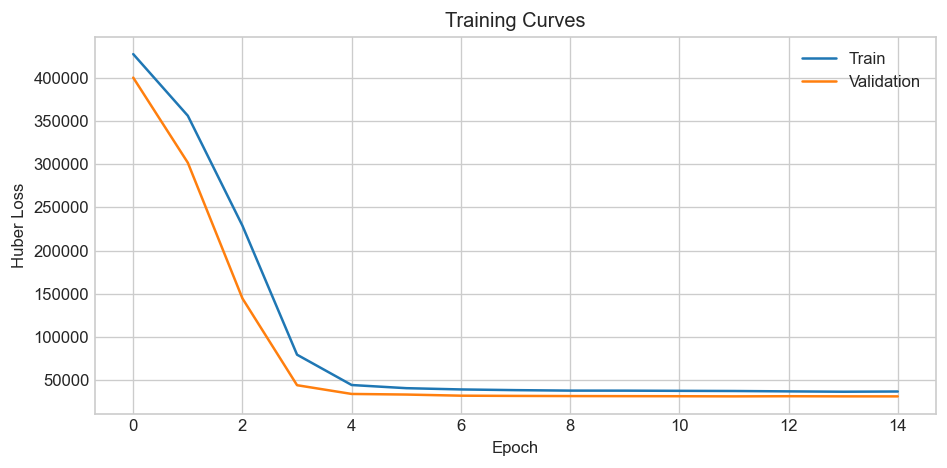

In [34]:
optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# cosine annealing is smoother than ReduceLROnPlateau for this task
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=LR * 0.05)
# Huber with delta~150 is more robust to the long Elo tails than plain MSE
loss_fn    = nn.HuberLoss(delta=150.0)
scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)
time_model = time.time()
train_losses, val_losses = [], []
best_val, patience_ctr   = float('inf'), 0
model_name = f'chess_elo_v2_time_{time_model:.0f}_{MAX_GAMES:.0e}.pth'

for epoch in range(NUM_EPOCHS):
    t_ep = time.time()

    # ── train ──────────────────────────────────────────────────────────────
    model.train()
    running, n_b = 0.0, 0
    for batch in train_loader:
        mv   = batch['moves'].to(device, non_blocking=True)
        cl   = batch['clocks'].to(device, non_blocking=True)
        tu   = batch['turns'].to(device, non_blocking=True)
        mask = batch['mask'].to(device, non_blocking=True)
        st   = batch['static'].to(device, non_blocking=True)
        tgt  = batch['targets'].to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            wp, bp, _ = model(mv, cl, tu, mask, st)
            loss = loss_fn(wp, tgt[:, 0]) + loss_fn(bp, tgt[:, 1])

        optimizer.zero_grad(set_to_none=True)
        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()
        running += loss.item(); n_b += 1

    train_losses.append(running / max(n_b, 1))
    scheduler.step()

    # ── validate ───────────────────────────────────────────────────────────
    model.eval()
    val_run, val_n = 0.0, 0
    all_wp, all_bp, all_wt, all_bt = [], [], [], []
    with torch.no_grad():
        for batch in val_loader:
            mv   = batch['moves'].to(device)
            cl   = batch['clocks'].to(device)
            tu   = batch['turns'].to(device)
            mask = batch['mask'].to(device)
            st   = batch['static'].to(device)
            tgt  = batch['targets'].to(device)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                wp, bp, _ = model(mv, cl, tu, mask, st)
                loss = loss_fn(wp, tgt[:, 0]) + loss_fn(bp, tgt[:, 1])
            val_run += loss.item(); val_n += 1
            all_wp.extend(wp.cpu().numpy()); all_bp.extend(bp.cpu().numpy())
            all_wt.extend(tgt[:, 0].cpu().numpy())
            all_bt.extend(tgt[:, 1].cpu().numpy())

    val_loss = val_run / max(val_n, 1)
    val_losses.append(val_loss)
    w_mae = mean_absolute_error(all_wt, all_wp)
    b_mae = mean_absolute_error(all_bt, all_bp)
    cur_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS}  '
          f'train {train_losses[-1]:7.1f}  val {val_loss:7.1f}  '
          f'MAE W:{w_mae:.0f} B:{b_mae:.0f}  '
          f'lr {cur_lr:.2e}  {time.time()-t_ep:.1f}s')

    min_delta = best_val * REL_DELTA if best_val < float('inf') else 0.0
    if val_loss < best_val - min_delta:
        best_val, patience_ctr = val_loss, 0
        torch.save(model.state_dict(), model_name)
    else:
        patience_ctr += 1
        print(f'  No improvement (best {best_val:.1f}), patience {patience_ctr}/{PATIENCE}')
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train', lw=1.5)
ax.plot(val_losses,   label='Validation', lw=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
ax.set_title('Training Curves'); ax.legend()
plt.tight_layout(); plt.show()

## Evaluation

In [35]:
model.load_state_dict(torch.load(model_name, map_location=device, weights_only=True))
model.eval()
print(f'Loaded: {model_name}')

wp_all, bp_all, wt_all, bt_all = [], [], [], []
with torch.no_grad():
    for batch in test_loader:
        mv   = batch['moves'].to(device)
        cl   = batch['clocks'].to(device)
        tu   = batch['turns'].to(device)
        mask = batch['mask'].to(device)
        st   = batch['static'].to(device)
        tgt  = batch['targets'].to(device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            wp, bp, _ = model(mv, cl, tu, mask, st)
        wp_all.extend(wp.cpu().numpy()); bp_all.extend(bp.cpu().numpy())
        wt_all.extend(tgt[:, 0].cpu().numpy())
        bt_all.extend(tgt[:, 1].cpu().numpy())

wp_all = np.array(wp_all); bp_all = np.array(bp_all)
wt_all = np.array(wt_all); bt_all = np.array(bt_all)

w_mae = mean_absolute_error(wt_all, wp_all)
b_mae = mean_absolute_error(bt_all, bp_all)
w_med = median_absolute_error(wt_all, wp_all)
b_med = median_absolute_error(bt_all, bp_all)
all_err = np.concatenate([np.abs(wp_all-wt_all), np.abs(bp_all-bt_all)])

print(f'MAE    — White: {w_mae:.1f}  Black: {b_mae:.1f}  Combined: {(w_mae+b_mae)/2:.1f}')
print(f'Median — White: {w_med:.1f}  Black: {b_med:.1f}')
print(f'Within 100 Elo: {np.mean(all_err<100)*100:.1f}%')
print(f'Within 200 Elo: {np.mean(all_err<200)*100:.1f}%')
print(f'Within 300 Elo: {np.mean(all_err<300)*100:.1f}%')

Loaded: chess_elo_v2_2e+05.pth
MAE    — White: 163.1  Black: 160.2  Combined: 161.6
Median — White: 133.8  Black: 136.0
Within 100 Elo: 37.8%
Within 200 Elo: 67.9%
Within 300 Elo: 86.3%


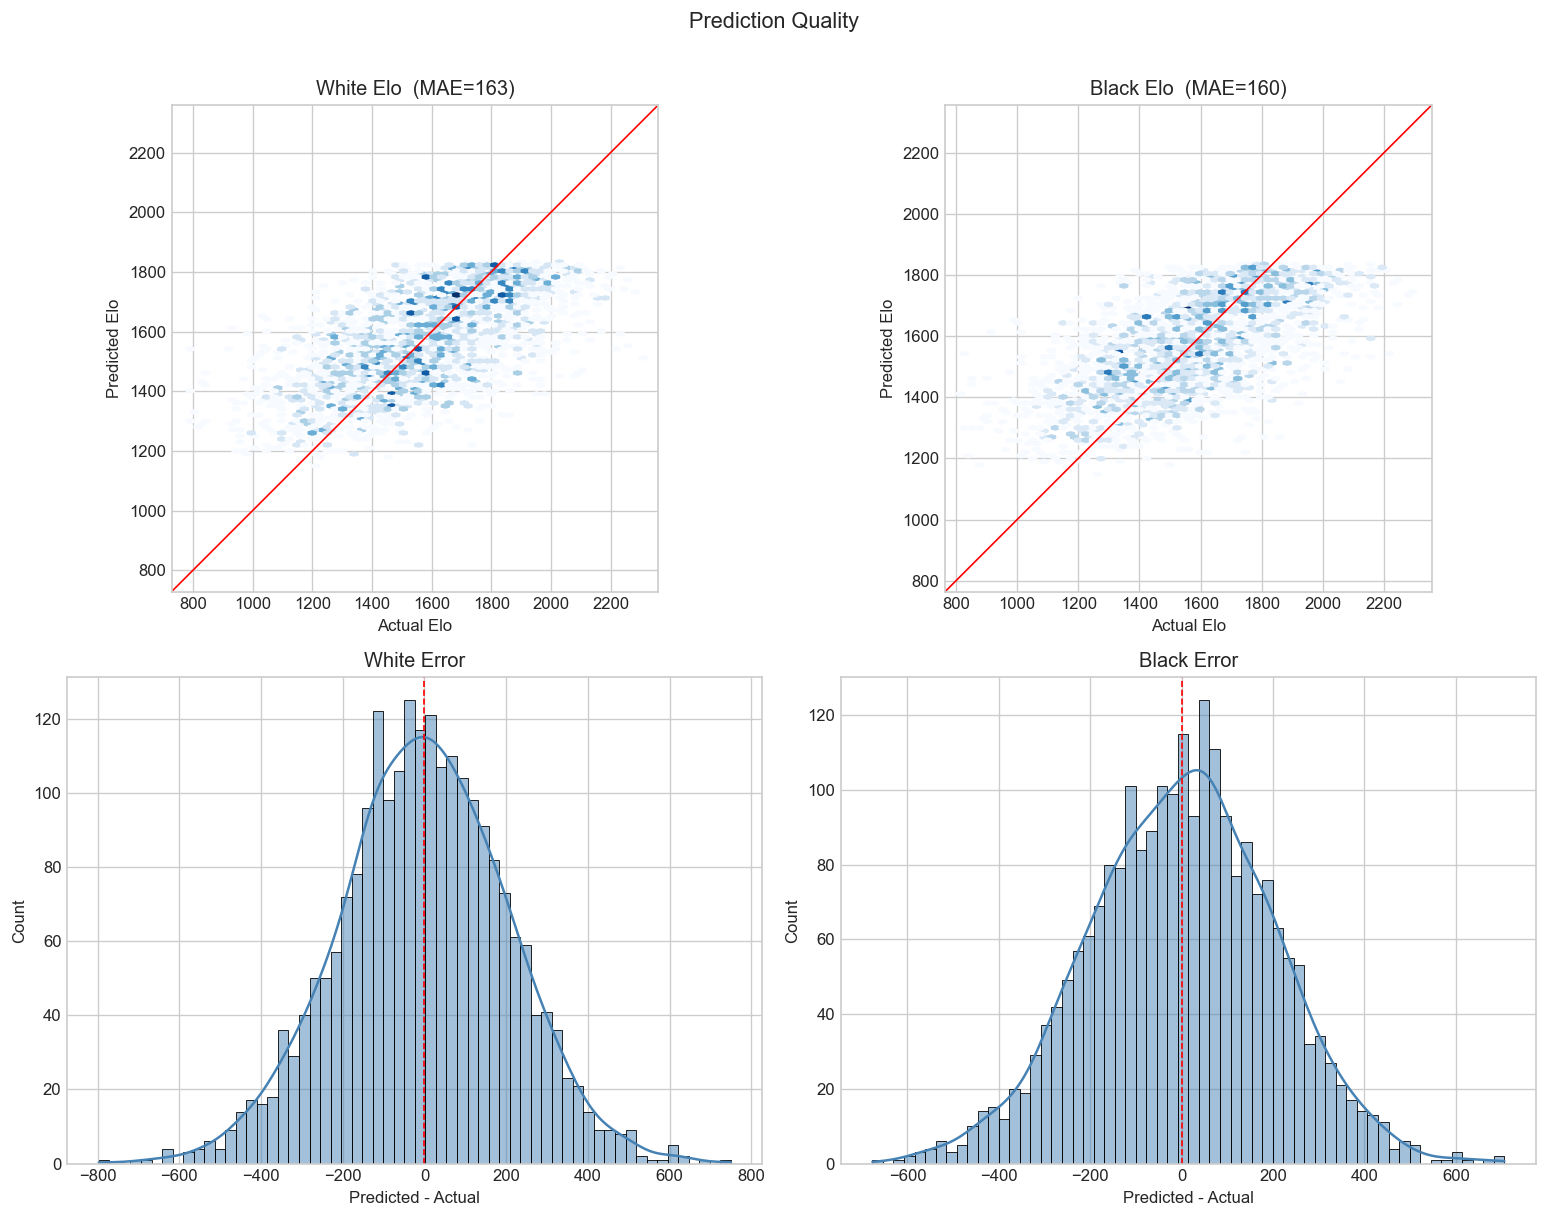

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, preds, trues, label in [
    (axes[0, 0], wp_all, wt_all, 'White Elo'),
    (axes[0, 1], bp_all, bt_all, 'Black Elo'),
]:
    lo = min(trues.min(), preds.min()) - 50
    hi = max(trues.max(), preds.max()) + 50
    ax.hexbin(trues, preds, gridsize=60, cmap='Blues', mincnt=1)
    ax.plot([lo, hi], [lo, hi], 'r-', lw=1)
    ax.set_xlabel('Actual Elo'); ax.set_ylabel('Predicted Elo')
    ax.set_title(f'{label}  (MAE={mean_absolute_error(trues, preds):.0f})')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')

for ax, preds, trues, label in [
    (axes[1, 0], wp_all, wt_all, 'White Error'),
    (axes[1, 1], bp_all, bt_all, 'Black Error'),
]:
    err = preds - trues
    sns.histplot(err, bins=60, kde=True, ax=ax, color='steelblue')
    ax.axvline(0, color='red', lw=1, ls='--')
    ax.set_xlabel('Predicted - Actual'); ax.set_title(label)

plt.suptitle('Prediction Quality', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

MAE by Elo bracket:
----------------------------------------
           (0, 1000]  MAE=  449  n=59
        (1000, 1200]  MAE=  262  n=308
        (1200, 1400]  MAE=  163  n=872
        (1400, 1600]  MAE=  117  n=1,277
        (1600, 1800]  MAE=  115  n=1,211
        (1800, 2000]  MAE=  199  n=695
        (2000, 2200]  MAE=  354  n=168
        (2200, 2500]  MAE=  551  n=16


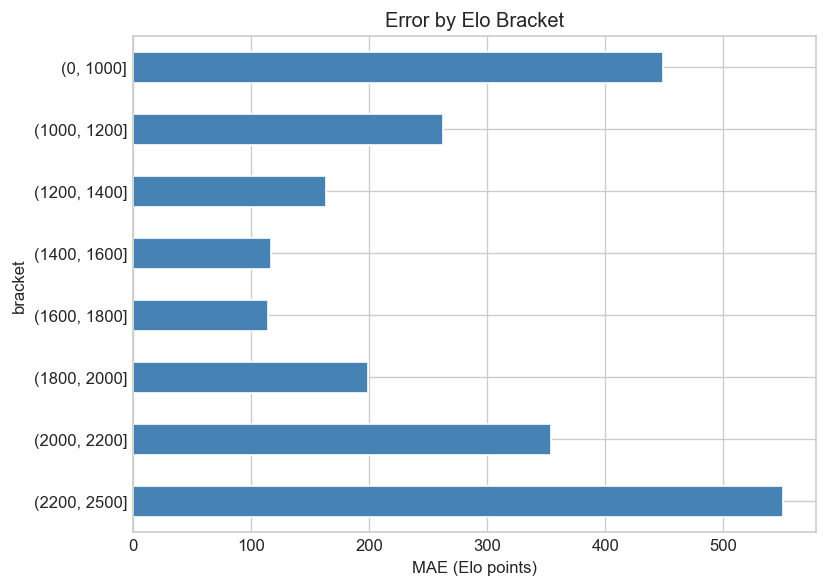

In [37]:
all_true = np.concatenate([wt_all, bt_all])
all_pred = np.concatenate([wp_all, bp_all])

bin_labels  = pd.cut(all_true, bins=ELO_BINS, right=True)
bracket_df  = pd.DataFrame({'true': all_true, 'pred': all_pred, 'bracket': bin_labels})
bracket_mae = bracket_df.groupby('bracket', observed=True).apply(
    lambda g: mean_absolute_error(g['true'], g['pred'])).sort_index()
bracket_n   = bracket_df.groupby('bracket', observed=True).size().sort_index()

print('MAE by Elo bracket:')
print('-' * 40)
for b, mae in bracket_mae.items():
    print(f'  {str(b):>18s}  MAE={mae:5.0f}  n={bracket_n[b]:,}')

fig, ax = plt.subplots(figsize=(7, 5))
bracket_mae.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('MAE (Elo points)')
ax.set_title('Error by Elo Bracket')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## What the Model Learned

### Attention Heatmap

Game: 40 plies  |  White 1199 (pred 1384)  |  Black 1177 (pred 1383)


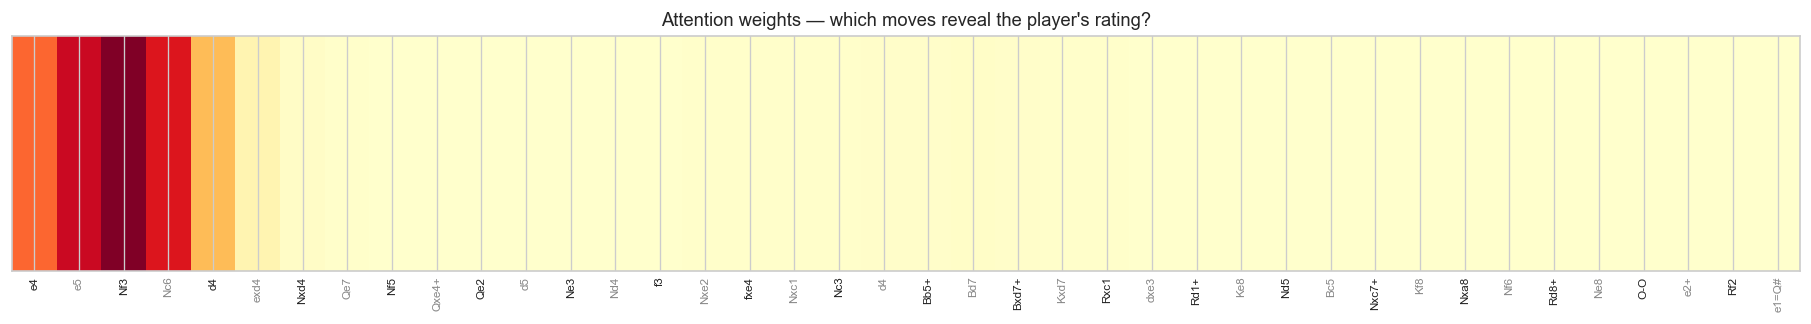

In [38]:
if not USE_SEQUENTIAL:
    print('Attention heatmap requires USE_SEQUENTIAL=True.')
else:
    test_df = df.loc[idx_test].reset_index(drop=True)
    candidates = test_df[test_df['n_moves'].between(28, 45)]
    if candidates.empty:
        candidates = test_df
    game_idx = candidates.index[0]

    sample = test_ds[game_idx]
    with torch.no_grad():
        mv   = sample['moves'].unsqueeze(0).to(device)
        cl   = sample['clocks'].unsqueeze(0).to(device)
        tu   = sample['turns'].unsqueeze(0).to(device)
        mask = (mv != 0).float()
        st   = sample['static'].unsqueeze(0).to(device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            wp, bp, attn = model(mv, cl, tu, mask, st)

    seq_len   = int(mask.sum().item())
    attn_np   = attn.cpu().float().numpy().squeeze()[:seq_len]
    moves_vis = test_df.iloc[game_idx]['clean_moves'][:seq_len]

    print(f'Game: {seq_len} plies  |  '
          f'White {test_df.iloc[game_idx].WhiteElo} (pred {wp.item():.0f})  |  '
          f'Black {test_df.iloc[game_idx].BlackElo} (pred {bp.item():.0f})')

    fig, ax = plt.subplots(figsize=(max(12, seq_len*0.38), 2.8))
    ax.imshow(attn_np.reshape(1, -1), aspect='auto', cmap='YlOrRd')
    ax.set_yticks([])
    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(moves_vis, rotation=90, fontsize=7)
    colors = ['#222' if i%2==0 else '#888' for i in range(seq_len)]
    for lbl, c in zip(ax.get_xticklabels(), colors):
        lbl.set_color(c)
    ax.set_title("Attention weights — which moves reveal the player's rating?", fontsize=11)
    plt.tight_layout(); plt.show()

### Progressive Elo Estimation

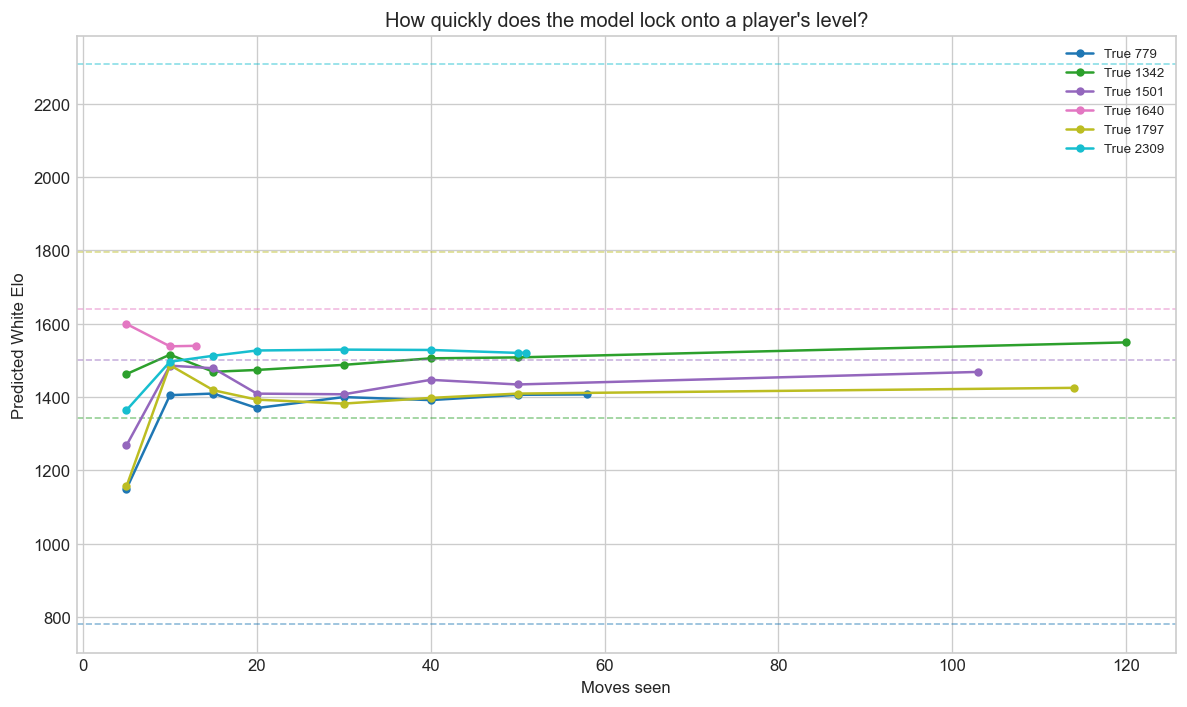

In [39]:
if not USE_SEQUENTIAL:
    print('Progressive estimation requires USE_SEQUENTIAL=True.')
else:
    test_df_s  = test_df.sort_values('WhiteElo')
    pick_idx   = np.linspace(0, len(test_df_s)-1, 6, dtype=int)
    samp_games = test_df_s.iloc[pick_idx]
    cuts       = [5, 10, 15, 20, 30, 40, 50]

    fig, ax = plt.subplots(figsize=(10, 6))
    palette = plt.cm.tab10(np.linspace(0, 1, len(samp_games)))

    for (_, row), color in zip(samp_games.iterrows(), palette):
        gi = test_df.index.get_loc(row.name) if row.name in test_df.index else None
        if gi is None:
            continue
        samp   = test_ds[gi]
        flen   = int((samp['moves'] != 0).sum().item())
        c_list = [c for c in cuts if c < flen] + [flen]
        preds  = []
        for cut in c_list:
            with torch.no_grad():
                mv_t = samp['moves'][:cut].unsqueeze(0).to(device)
                cl_t = samp['clocks'][:cut].unsqueeze(0).to(device)
                tu_t = samp['turns'][:cut].unsqueeze(0).to(device)
                st_t = samp['static'].unsqueeze(0).to(device)
                with torch.cuda.amp.autocast(enabled=USE_AMP):
                    wpp, _, _ = model(mv_t, cl_t, tu_t, (mv_t!=0).float(), st_t)
                preds.append(wpp.item())
        ax.plot(c_list, preds, 'o-', color=color, ms=4, label=f'True {row.WhiteElo}')
        ax.axhline(row.WhiteElo, color=color, ls='--', alpha=0.5, lw=1)

    ax.set_xlabel('Moves seen'); ax.set_ylabel('Predicted White Elo')
    ax.set_title("How quickly does the model lock onto a player's level?")
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout(); plt.show()

### Latent Space — t-SNE & UMAP

C:\Users\EliasBenSlama\AppData\Local\Temp\ipykernel_33352\302162917.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_d     = plt.cm.get_cmap('viridis', len(labels_vis))


Running t-SNE on 2303 vectors...


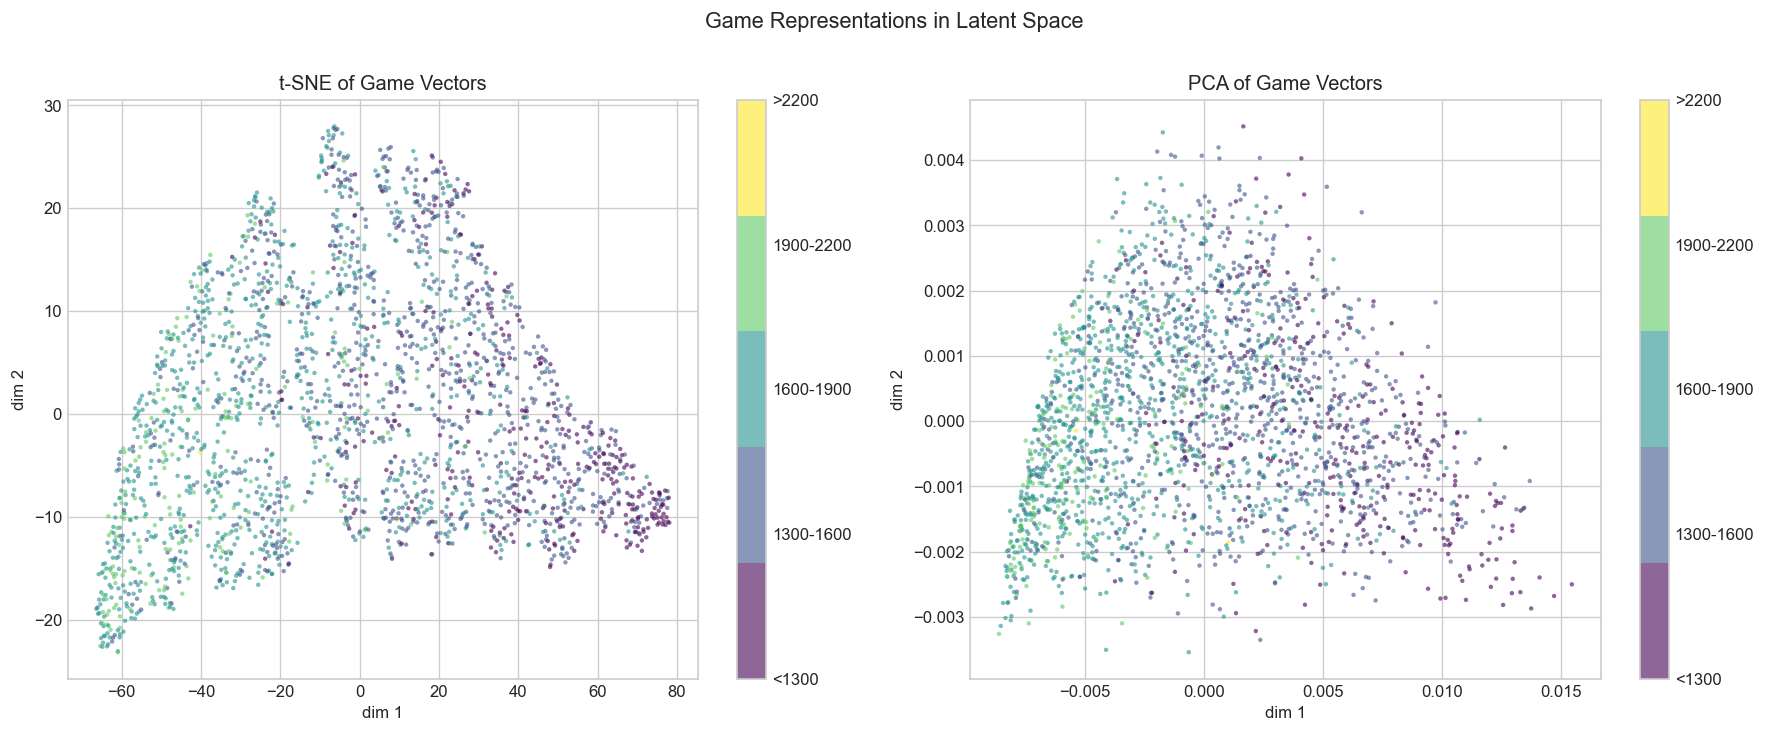

In [40]:
N_VIS = min(3000, len(test_ds))
vectors, elo_vis = [], []
model.eval()

with torch.no_grad():
    tsne_loader = DataLoader(
        torch.utils.data.Subset(test_ds, range(N_VIS)),
        batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    for batch in tsne_loader:
        mv  = batch['moves'].to(device); cl = batch['clocks'].to(device)
        tu  = batch['turns'].to(device); mask = batch['mask'].to(device)
        st  = batch['static'].to(device); tgt  = batch['targets']
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            vecs = model.get_game_vector(mv, cl, tu, mask, st)
        vectors.append(vecs.cpu().float().numpy())
        elo_vis.extend(((tgt[:,0]+tgt[:,1])/2).numpy())

vectors  = np.vstack(vectors)
elo_vis  = np.array(elo_vis[:len(vectors)])
v_norm   = normalize(vectors, norm='l2')

bins_vis   = [0, 1300, 1600, 1900, 2200, 4000]
labels_vis = ['<1300', '1300-1600', '1600-1900', '1900-2200', '>2200']
bin_codes  = pd.cut(elo_vis, bins=bins_vis, labels=labels_vis).codes
cmap_d     = plt.cm.get_cmap('viridis', len(labels_vis))

print(f'Running t-SNE on {len(v_norm)} vectors...')
emb_tsne = TSNE(n_components=2, perplexity=40,
                random_state=RANDOM_STATE, max_iter=1000).fit_transform(v_norm)
emb_pca2 = PCA(n_components=2).fit_transform(v_norm)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, emb, title in [(axes[0], emb_tsne, 't-SNE'), (axes[1], emb_pca2, 'PCA')]:
    sc = ax.scatter(emb[:,0], emb[:,1], c=bin_codes, cmap=cmap_d,
                    s=7, alpha=0.6, edgecolors='none')
    cbar = plt.colorbar(sc, ax=ax, ticks=range(len(labels_vis)))
    cbar.ax.set_yticklabels(labels_vis)
    ax.set_title(f'{title} of Game Vectors')
    ax.set_xlabel('dim 1'); ax.set_ylabel('dim 2')
plt.suptitle('Game Representations in Latent Space', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

Running UMAP...


c:\Users\EliasBenSlama\Anaconda3\envs\AppliedML\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


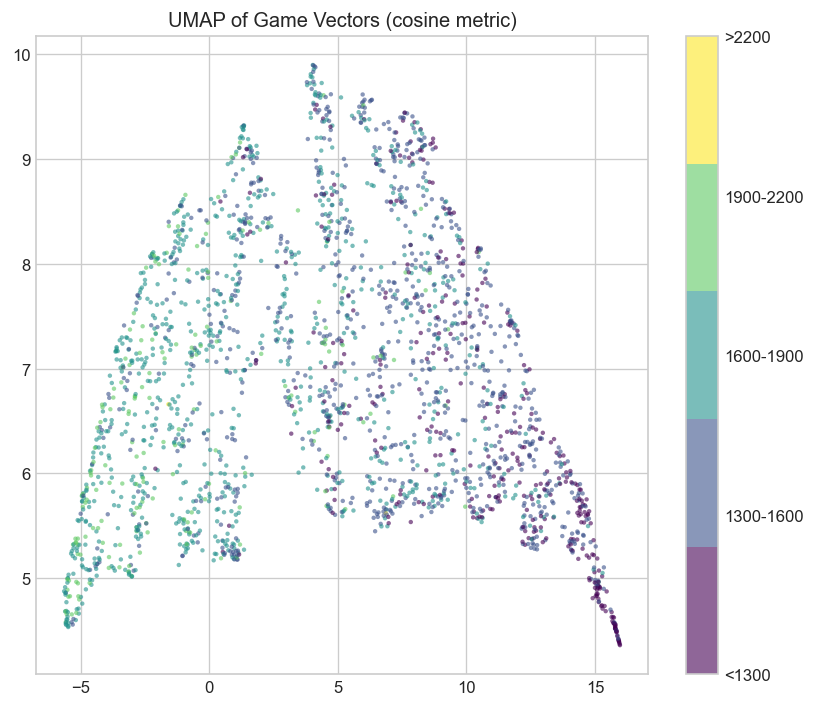

In [41]:
try:
    import umap as umap_lib
    print('Running UMAP...')
    emb_umap = umap_lib.UMAP(n_neighbors=30, min_dist=0.1,
                              metric='cosine', random_state=RANDOM_STATE
                              ).fit_transform(v_norm)
    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(emb_umap[:,0], emb_umap[:,1], c=bin_codes, cmap=cmap_d,
                    s=7, alpha=0.6, edgecolors='none')
    cbar = plt.colorbar(sc, ax=ax, ticks=range(len(labels_vis)))
    cbar.ax.set_yticklabels(labels_vis)
    ax.set_title('UMAP of Game Vectors (cosine metric)')
    plt.tight_layout(); plt.show()
except ImportError:
    print('umap-learn not installed, skipping.  pip install umap-learn')

### Move Embedding Space

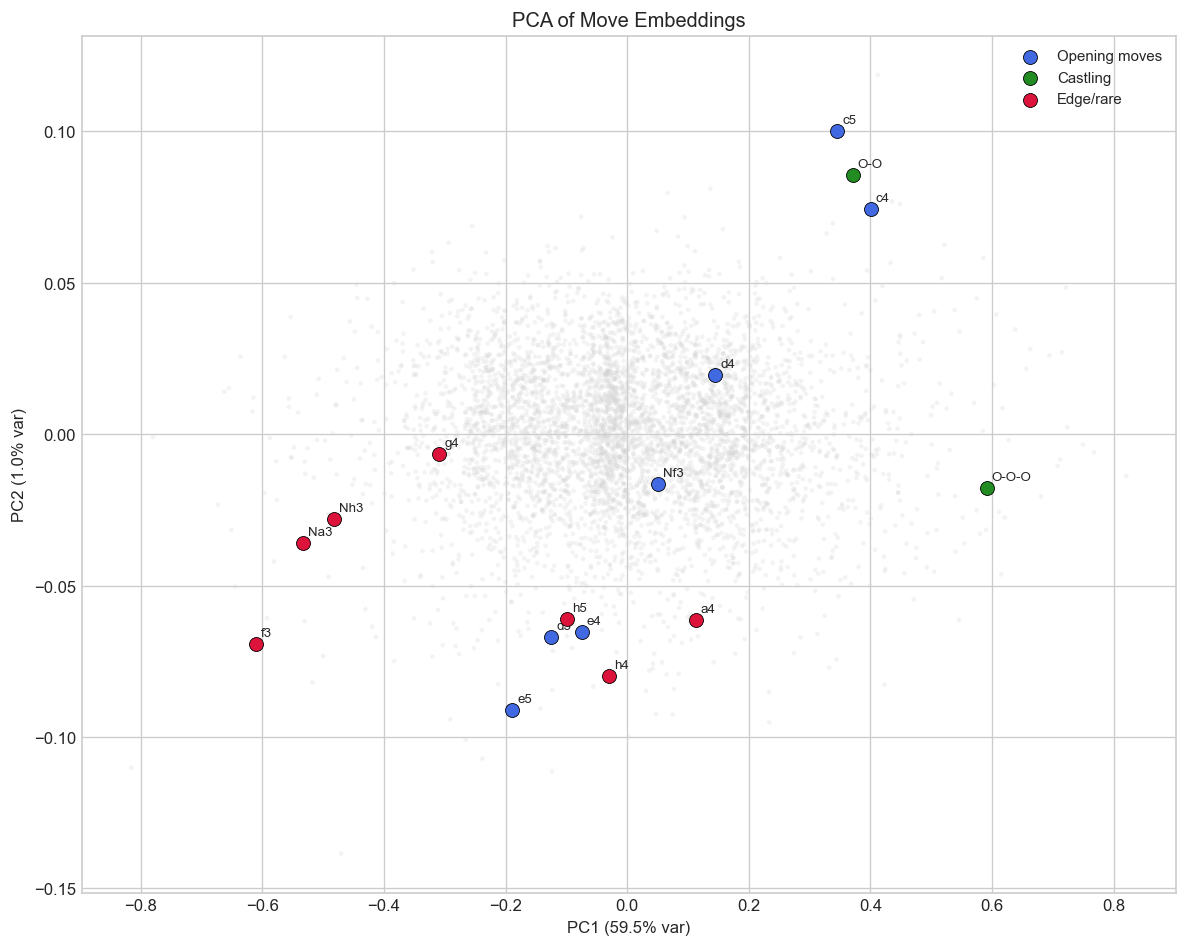

In [42]:
if not USE_SEQUENTIAL:
    print('Move embeddings only available when USE_SEQUENTIAL=True.')
else:
    emb_w = model.move_embed.weight.detach().cpu().float().numpy()
    pca_e = PCA(n_components=2)
    emb_p = pca_e.fit_transform(emb_w)

    highlight = {
        'Opening moves': (['e4','d4','c4','Nf3','e5','c5','d5'], 'royalblue'),
        'Castling':      (['O-O','O-O-O'], 'forestgreen'),
        'Edge/rare':     (['h4','a4','Na3','Nh3','h5','g4','f3'], 'crimson'),
    }

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(emb_p[:,0], emb_p[:,1], c='lightgray', s=8, alpha=0.25, edgecolors='none')
    for gname, (mvs, col) in highlight.items():
        first = True
        for m in mvs:
            if m not in vocab.move_to_id: continue
            idx = vocab.move_to_id[m]
            ax.scatter(emb_p[idx,0], emb_p[idx,1], c=col, s=70,
                       edgecolors='black', lw=0.5, zorder=5,
                       label=gname if first else None)
            ax.annotate(m, (emb_p[idx,0], emb_p[idx,1]),
                        fontsize=8, ha='left', va='bottom',
                        xytext=(3,3), textcoords='offset points')
            first = False
    ax.legend(fontsize=9)
    ax.set_title('PCA of Move Embeddings')
    ax.set_xlabel(f'PC1 ({pca_e.explained_variance_ratio_[0]:.1%} var)')
    ax.set_ylabel(f'PC2 ({pca_e.explained_variance_ratio_[1]:.1%} var)')
    plt.tight_layout(); plt.show()

### Feature Importance — Integrated Gradients

c:\Users\EliasBenSlama\Anaconda3\envs\AppliedML\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(


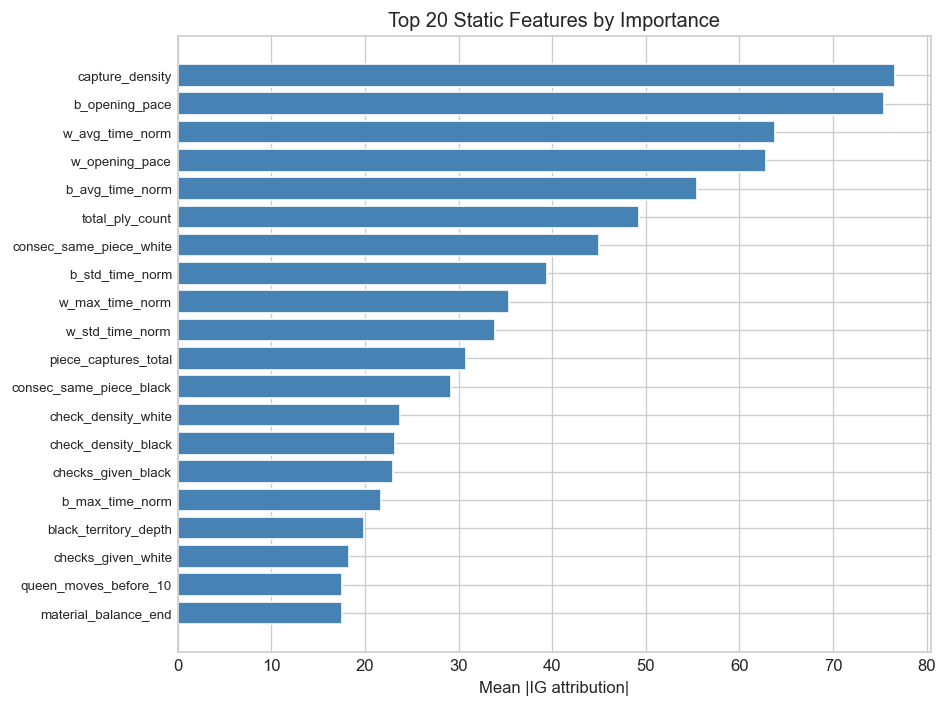

01. capture_density: 76.6061
02. b_opening_pace: 75.4814
03. w_avg_time_norm: 63.8405
04. w_opening_pace: 62.8505
05. b_avg_time_norm: 55.4906
06. total_ply_count: 49.2685
07. consec_same_piece_white: 45.0169
08. b_std_time_norm: 39.4407
09. w_max_time_norm: 35.3950
10. w_std_time_norm: 33.8600
11. piece_captures_total: 30.7776
12. consec_same_piece_black: 29.2127
13. check_density_white: 23.7275
14. check_density_black: 23.1975
15. checks_given_black: 22.9867
16. b_max_time_norm: 21.6766
17. black_territory_depth: 19.8697
18. checks_given_white: 18.2430
19. queen_moves_before_10: 17.5291
20. material_balance_end: 17.5166


In [44]:
try:
    from captum.attr import IntegratedGradients

    model.eval()
    batch = next(iter(test_loader))
    mv_ig = batch['moves'].to(device); cl_ig = batch['clocks'].to(device)
    tu_ig = batch['turns'].to(device); mask_ig = batch['mask'].to(device)
    st_ig = batch['static'].to(device)

    def _fwd_st(x, mv, cl, tu, mask):
        w, b, _ = model(mv, cl, tu, mask, x)
        return (w + b) / 2

    ig = IntegratedGradients(_fwd_st)
    attr = ig.attribute(
        st_ig,
        baselines=torch.zeros_like(st_ig),
        additional_forward_args=(mv_ig, cl_ig, tu_ig, mask_ig),
        n_steps=32,
        internal_batch_size=1
    )
    imp  = attr.abs().mean(0).cpu().numpy()
    top  = sorted(zip(static_cols, imp), key=lambda x: x[1], reverse=True)[:20]
    names, vals = zip(*top)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(range(len(names)), list(vals)[::-1], color='steelblue', edgecolor='white')
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(list(names)[::-1], fontsize=8)
    ax.set_xlabel('Mean |IG attribution|')
    ax.set_title('Top 20 Static Features by Importance')
    plt.tight_layout(); plt.show()

    for i, (n, v) in enumerate(top, 1):
        print(f'{i:02d}. {n}: {v:.4f}')
except ImportError:
    print('captum not installed, skipping.  pip install captum')

### Feature Group Importance — Ablation

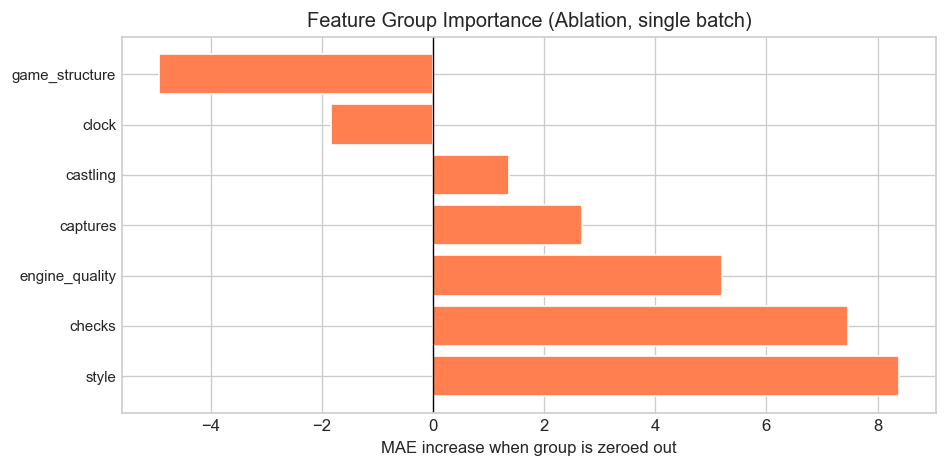

  style               delta MAE = +8.4
  checks              delta MAE = +7.5
  engine_quality      delta MAE = +5.2
  captures            delta MAE = +2.7
  castling            delta MAE = +1.4
  clock               delta MAE = -1.8
  game_structure      delta MAE = -4.9

game_structure (3 cols):
  total_ply_count
  material_balance_end
  result_encoded

checks (4 cols):
  checks_given_white
  checks_given_black
  check_density_white
  check_density_black

captures (5 cols):
  first_capture_move_white
  first_capture_move_black
  pawn_captures_total
  piece_captures_total
  capture_density

castling (2 cols):
  castle_move_white
  castle_move_black

style (9 cols):
  consec_same_piece_white
  consec_same_piece_black
  queen_moves_before_10
  white_territory_depth
  black_territory_depth
  promotions
  en_passant_captures
  legal_moves_white_move5
  legal_moves_black_move5

engine_quality (10 cols):
  acpl_white
  inaccuracy_count_white
  mistake_count_white
  blunder_count_white
  blu

In [49]:
model.eval()
b0   = next(iter(test_loader))
mv0  = b0['moves'].to(device); cl0 = b0['clocks'].to(device)
tu0  = b0['turns'].to(device); mask0 = b0['mask'].to(device)
st0  = b0['static'].to(device); tgt0 = b0['targets']

with torch.no_grad():
    wp0, bp0, _ = model(mv0, cl0, tu0, mask0, st0)
base_mae = (mean_absolute_error(tgt0[:,0].numpy(), wp0.cpu().numpy()) +
            mean_absolute_error(tgt0[:,1].numpy(), bp0.cpu().numpy()))

group_delta = {}
for grp, prefixes in _GROUP_PREFIXES.items():
    if not FEATURE_GROUPS.get(grp, False): continue
    grp_idx = [i for i,c in enumerate(static_cols)
                if any(c.startswith(p) for p in prefixes)]
    if not grp_idx: continue
    st_m = st0.clone(); st_m[:, grp_idx] = 0.0
    with torch.no_grad():
        wpm, bpm, _ = model(mv0, cl0, tu0, mask0, st_m)
    masked_mae = (mean_absolute_error(tgt0[:,0].numpy(), wpm.cpu().numpy()) +
                  mean_absolute_error(tgt0[:,1].numpy(), bpm.cpu().numpy()))
    group_delta[grp] = masked_mae - base_mae

if group_delta:
    grps, deltas = zip(*sorted(group_delta.items(), key=lambda x: -x[1]))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(range(len(grps)), deltas, color='coral', edgecolor='white')
    ax.set_yticks(range(len(grps))); ax.set_yticklabels(grps, fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('MAE increase when group is zeroed out')
    ax.set_title('Feature Group Importance (Ablation, single batch)')
    plt.tight_layout(); plt.show()
    for g, d in zip(grps, deltas):
        print(f'  {g:<18s}  delta MAE = {d:+.1f}')

#Show what is in each feature group for reference
for group, active in FEATURE_GROUPS.items():
    if not active: continue
    prefixes = _GROUP_PREFIXES.get(group, [])
    cols = [c for c in static_cols if any(c.startswith(p) for p in prefixes)]
    print(f'\n{group} ({len(cols)} cols):')
    for c in cols:
        print(f'  {c}')

### Anomaly Detection — Suspicious Over/Underperformers

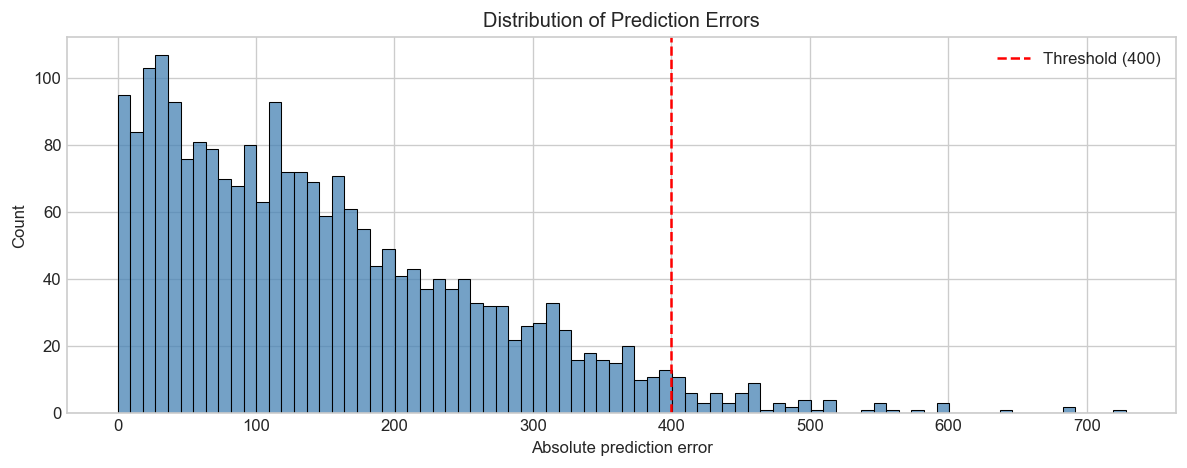

Flagged 73 games with |error| > 400  (3.2%)

Top 15 OVERPERFORMERS (model rates them above their actual Elo)
   Predicted      Actual      Diff
  --------------------------------
        1544         816      +728
        1615         926      +689
        1653        1010      +642
        1464         866      +598
        1437         842      +595
        1641        1064      +577
        1599        1081      +518
        1595        1083      +512
        1681        1182      +499
        1305         808      +497
        1458         974      +484
        1537        1072      +466
        1511        1046      +464
        1401         938      +463
        1616        1155      +461

Top 15 UNDERPERFORMERS (model rates them below their actual Elo)
   Predicted      Actual      Diff
  --------------------------------
        1541        2225      -684
        1597        2193      -596
        1512        2075      -563
        1535        2088      -553
        1537        

In [51]:
avg_pred  = (wp_all + bp_all) / 2
avg_true  = (wt_all + bt_all) / 2
diff      = avg_pred - avg_true
abs_diff  = np.abs(diff)
THRESHOLD = 400

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(abs_diff, bins=80, ax=ax, color='steelblue')
ax.axvline(THRESHOLD, color='red', ls='--', lw=1.5, label=f'Threshold ({THRESHOLD})')
ax.set_xlabel('Absolute prediction error'); ax.set_ylabel('Count')
ax.set_title('Distribution of Prediction Errors'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Flagged {np.sum(abs_diff>THRESHOLD)} games with |error| > {THRESHOLD}  '
      f'({np.mean(abs_diff>THRESHOLD)*100:.1f}%)\n')

for title, order in [
    ('Top 15 OVERPERFORMERS (model rates them above their actual Elo)',
     np.argsort(diff)[::-1][:15]),
    ('Top 15 UNDERPERFORMERS (model rates them below their actual Elo)',
     np.argsort(diff)[:15]),
]:
    print(title)
    print(f"  {'Predicted':>10s}  {'Actual':>10s}  {'Diff':>8s}")
    print('  ' + '-'*32)
    for i in order:
        print(f'  {avg_pred[i]:10.0f}  {avg_true[i]:10.0f}  {diff[i]:+8.0f}')
    print()

### Opening Analysis (ECO codes)

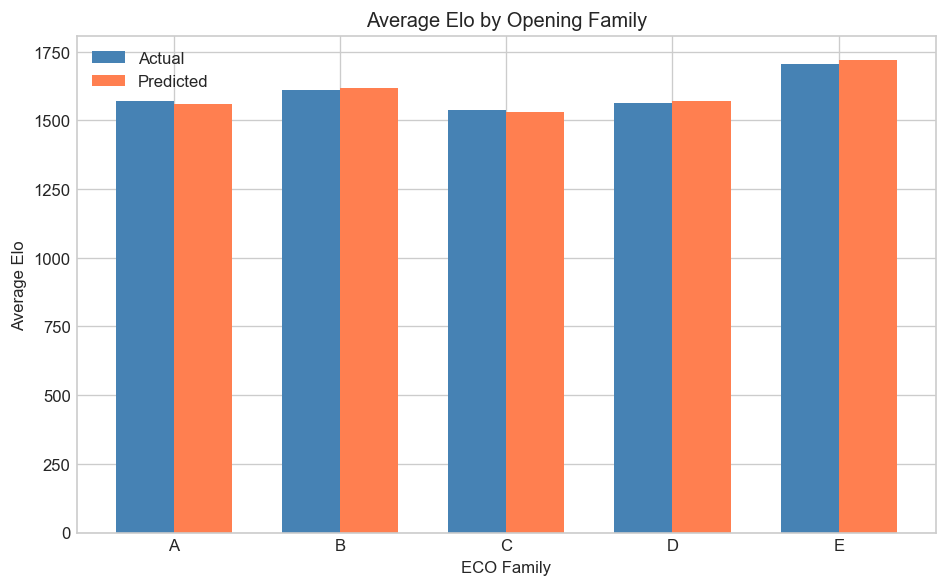

Top 5 highest-Elo ECO codes (min 10 games):
    B30  avg Elo: 1732  (n=31)
    B32  avg Elo: 1713  (n=10)
    B10  avg Elo: 1708  (n=27)
    A20  avg Elo: 1705  (n=10)
    C01  avg Elo: 1701  (n=18)

Bottom 5 lowest-Elo ECO codes (min 10 games):
    C20  avg Elo: 1408  (n=133)
    C40  avg Elo: 1415  (n=49)
    C68  avg Elo: 1421  (n=10)
    D01  avg Elo: 1424  (n=12)
    C22  avg Elo: 1449  (n=14)



In [52]:
test_df_eval = df.loc[idx_test].reset_index(drop=True)

if 'ECO' in test_df_eval.columns:
    eco_df = pd.DataFrame({
        'ECO':      test_df_eval['ECO'].values[:len(avg_true)],
        'avg_true': avg_true,
        'avg_pred': avg_pred,
    })
    eco_df['eco_family'] = eco_df['ECO'].str[0]

    fstats = eco_df.groupby('eco_family').agg(
        actual=('avg_true','mean'), predicted=('avg_pred','mean'),
        count=('avg_true','count')).sort_index()

    fig, ax = plt.subplots(figsize=(8, 5))
    x, w = np.arange(len(fstats)), 0.35
    ax.bar(x-w/2, fstats['actual'],    w, label='Actual',    color='steelblue')
    ax.bar(x+w/2, fstats['predicted'], w, label='Predicted', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(fstats.index)
    ax.set_xlabel('ECO Family'); ax.set_ylabel('Average Elo')
    ax.set_title('Average Elo by Opening Family'); ax.legend()
    plt.tight_layout(); plt.show()

    eco_m = eco_df.groupby('ECO').agg(
        actual=('avg_true','mean'), count=('avg_true','count'))
    eco_m = eco_m[eco_m['count'] >= 10]
    for lbl, fn in [('Top 5 highest-Elo', 'nlargest'),
                    ('Bottom 5 lowest-Elo', 'nsmallest')]:
        print(f'{lbl} ECO codes (min 10 games):')
        for eco, row in getattr(eco_m, fn)(5, 'actual').iterrows():
            print(f'  {eco:>5s}  avg Elo: {row.actual:.0f}  (n={int(row["count"])})')
        print()
else:
    print('No ECO column found, skipping opening analysis.')

## Export Notebook as HTML

In [53]:
import subprocess, datetime

nb_path  = os.path.abspath('chess_elo_notebook_v2.ipynb')
out_dir  = os.path.abspath('output_files')
os.makedirs(out_dir, exist_ok=True)
ts       = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
out_html = os.path.join(out_dir, f'chess_elo_v2_{MAX_GAMES:.0e}_{ts}.html')

subprocess.run(
    ['jupyter', 'nbconvert', '--to', 'html',
     '--no-input', '--output', out_html, nb_path],
    check=True
)
print(f'Exported: {out_html}')

Exported: c:\CodeBases\AppML_FinalProject\root\workspace\elias_sandbox\output_files\chess_elo_v2_2e+05_20260603_132743.html
